# Prepare dataset

In [1]:
input_pages = '../output/dataset/pages-reviewed.jsonl'
output_review = '../input/review/from-convos.jsonl'
input_images = '../input/pkna/*/*.jp*g'
output_dataset = '../output/dataset/dataset.csv'

In [2]:
import json
from dataclasses import dataclass
import numpy as np


@dataclass
class Line:
    character: str
    text: str
    confidence: float
    uno_confidence: float

    def to_dict(self) -> dict:
        return {
            'character': self.character,
            'text': self.text,
            'confidence': self.confidence,
            'uno_confidence': self.uno_confidence,
        }

    @staticmethod
    def from_dict(data: dict) -> 'Line':
        return Line(
            character=data['character'],
            text=data['text'],
            confidence=data['confidence'],
            uno_confidence=data.get('uno_confidence', 0.0),
        )


@dataclass
class Page:
    input_page: str
    pkna: str
    page_num: int
    conv_num: int
    dialogue: list[Line]
    reviewed: bool

    def to_dict(self) -> dict:
        return {
            'input_page': self.input_page,
            'pkna': self.pkna,
            'page_num': self.page_num,
            'conv_num': self.conv_num,
            'dialogue': [d.to_dict() for d in self.dialogue],
            'reviewed': self.reviewed
        }

    @staticmethod
    def from_dict(data: dict) -> 'Page':
        return Page(
            input_page=data['input_page'],
            pkna=data['pkna'],
            page_num=data['page_num'],
            conv_num=data['conv_num'],
            dialogue=[Line.from_dict(line) for line in data['dialogue']],
            reviewed=data['reviewed'],
        )


# Load pages from the input file
with open(input_pages, 'r', encoding='utf-8') as f:
    pages = [
        Page.from_dict(json.loads(line))
        for line in f
    ]

## Fix page numbers

Unfortunately, the way we computed the page numbers in the previous steps is not
reliable, and I don't want to re-run the full pipeline to fix them.

I will just fix them here, because this is the only place where they are
important.

In [3]:
pages[0].to_dict()

{'input_page': '../input/pkna/pkna-0/pkna-0-029.jpg',
 'pkna': 'PKNA #0',
 'page_num': 29,
 'conv_num': 29,
 'dialogue': [{'character': 'paperinik',
   'text': 'Hai paura di affrontarmi? Fatti vedere!',
   'confidence': 0.984,
   'uno_confidence': 0.0},
  {'character': 'paperinik',
   'text': 'Veramente, mi stai già guardando!',
   'confidence': 1.0,
   'uno_confidence': 0.0},
  {'character': 'paperinik',
   'text': 'Io sono questo edificio!',
   'confidence': 0.5920000000000001,
   'uno_confidence': 0.4},
  {'character': 'paperinik',
   'text': 'Ma se proprio hai bisogno di un volto a cui rivolgerti... ecco!',
   'confidence': 0.5920000000000001,
   'uno_confidence': 0.4},
  {'character': 'paperinik',
   'text': 'Glom! Penso di averne viste abbastanza, per una sola notte!',
   'confidence': 1.0,
   'uno_confidence': 0.0},
  {'character': 'paperinik',
   'text': 'Facciamoci coraggio!',
   'confidence': 1.0,
   'uno_confidence': 0.0},
  {'character': 'paperinik',
   'text': 'Non so cosa

In [4]:
from glob import glob
from pathlib import Path
from collections import defaultdict

def compute_page_nums() -> dict[str, int]:
    # Glob all files in the input_images directory
    files = [Path(x) for x in sorted(glob(input_images))]
    # Map directory names to their image files
    per_issue: dict[str, list[str]] = defaultdict(list)
    for file in files:
        dir_name = file.parent.name
        per_issue[dir_name].append(str(file))

    # Compute page numbers for each issue
    page_nums: dict[str, int] = {}
    for issue, images in per_issue.items():
        for i, image in enumerate(images):
            page_nums[image] = i + 1  # Page numbers start from 1

    return page_nums

page_nums = compute_page_nums()

In [5]:
for page in pages:
    # Set page_num based on the computed page numbers
    page.page_num = page_nums[page.input_page]

pages[0].to_dict()

{'input_page': '../input/pkna/pkna-0/pkna-0-029.jpg',
 'pkna': 'PKNA #0',
 'page_num': 30,
 'conv_num': 29,
 'dialogue': [{'character': 'paperinik',
   'text': 'Hai paura di affrontarmi? Fatti vedere!',
   'confidence': 0.984,
   'uno_confidence': 0.0},
  {'character': 'paperinik',
   'text': 'Veramente, mi stai già guardando!',
   'confidence': 1.0,
   'uno_confidence': 0.0},
  {'character': 'paperinik',
   'text': 'Io sono questo edificio!',
   'confidence': 0.5920000000000001,
   'uno_confidence': 0.4},
  {'character': 'paperinik',
   'text': 'Ma se proprio hai bisogno di un volto a cui rivolgerti... ecco!',
   'confidence': 0.5920000000000001,
   'uno_confidence': 0.4},
  {'character': 'paperinik',
   'text': 'Glom! Penso di averne viste abbastanza, per una sola notte!',
   'confidence': 1.0,
   'uno_confidence': 0.0},
  {'character': 'paperinik',
   'text': 'Facciamoci coraggio!',
   'confidence': 1.0,
   'uno_confidence': 0.0},
  {'character': 'paperinik',
   'text': 'Non so cosa

## Join pages into conversations

In [6]:
@dataclass
class Conversation:
    pages: list[Page]
    score: float = 0.0

    @property
    def pkna(self) -> str:
        """Get the PKNA of the first page in the conversation."""
        return self.pages[0].pkna if self.pages else ''

    @property
    def characters(self) -> list[str]:
        """Get the set of characters in the conversation."""
        return sorted(list({
            line.character
            for page in self.pages
            for line in page.dialogue
        }))

    @property
    def characters_score(self) -> int:
        wanted = set(['uno', 'paperinik'])
        got = set(self.characters)
        positive = got.intersection(wanted)
        negative = got.difference(wanted)
        return len(positive)*3 - len(negative)

    @property
    def num_pages_score(self) -> int:
        return len(self.pages)

    @property
    def confidence_score(self) -> float:
        """Calculate the average confidence of the conversation."""
        confidences = [
            np.mean([line.confidence for line in page.dialogue])
            for page in self.pages
        ]
        return float(np.mean(confidences)) if confidences else 0.0

    def to_dict(self) -> dict:
        return {
            'pkna': self.pages[0].pkna,
            'page_range': [page.page_num for page in self.pages],
            'characters': self.characters,
            'score': self.score,
            'pages': [page.to_dict() for page in self.pages]
        }


conversations = []

curr_conv: list[Page] = []

for page in pages:
    if curr_conv and (curr_conv[-1].page_num + 1) != page.page_num:
        conversations.append(Conversation(pages=curr_conv))
        curr_conv = []
    curr_conv.append(page)
if curr_conv:
    conversations.append(Conversation(pages=curr_conv))

len(conversations)

398

In [7]:
# Compute the score through combination of softmax of the three scores
import numpy as np


def softmax(nums: list[int | float]) -> list[float]:
    exp_scores = np.exp(nums - np.max(nums))
    softmax_scores = exp_scores / np.sum(exp_scores)
    return softmax_scores.tolist()


def compute_scores(conversations: list[Conversation]) -> None:
    char_scores = softmax([c.characters_score for c in conversations])
    num_pages_scores = softmax([c.num_pages_score for c in conversations])
    confidence_scores = softmax([c.confidence_score for c in conversations])

    for i, conv in enumerate(conversations):
        conv.score = (
            0.4 * confidence_scores[i] +
            0.4 * char_scores[i] +
            0.2 * num_pages_scores[i]
        )

    # Sort conversations by score
    conversations.sort(key=lambda c: c.score, reverse=True)


compute_scores(conversations)
conversations[0].to_dict()

{'pkna': 'PKNA #2',
 'page_range': [4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 'characters': ['angus fangus',
  'everett ducklair',
  'paperinik',
  'uno',
  'woman with dark curly hair'],
 'score': 0.05080927427402708,
 'pages': [{'input_page': '../input/pkna/pkna-2/pkna2-06.jpg',
   'pkna': 'PKNA #2',
   'page_num': 4,
   'conv_num': 6,
   'dialogue': [{'character': 'everett ducklair',
     'text': 'Sei pronto, Paperinik?',
     'confidence': 0.6960000000000001,
     'uno_confidence': 0.2},
    {'character': 'uno',
     'text': 'Sto per escludere il collegamento! Tre... due... uno...',
     'confidence': 0.86,
     'uno_confidence': 1.0},
    {'character': 'uno',
     'text': '...Zero! Routine conclusa, fine connessione.',
     'confidence': 0.984,
     'uno_confidence': 1.0},
    {'character': 'paperinik',
     'text': "La prossima volta preferirei che l'uscita dal programma fosse meno brusca!",
     'confidence': 0.86,
     'uno_confidence': 0.0},
    {'character': 'paperinik',
     'text

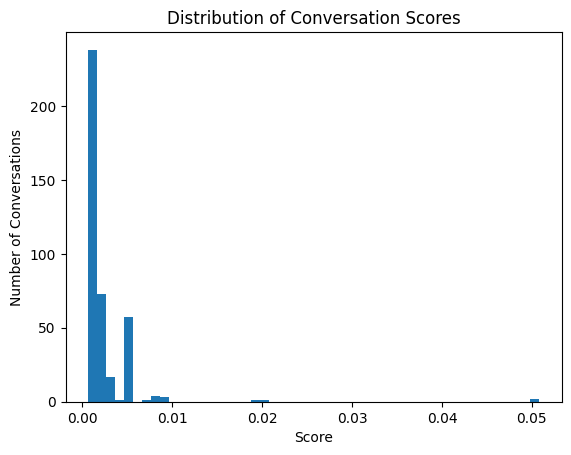

In [8]:
# Plot the distribution of scores
import matplotlib.pyplot as plt

scores = [conv.score for conv in conversations]
plt.hist(scores, bins=50)
plt.xlabel("Score")
plt.ylabel("Number of Conversations")
plt.title("Distribution of Conversation Scores")
plt.show()

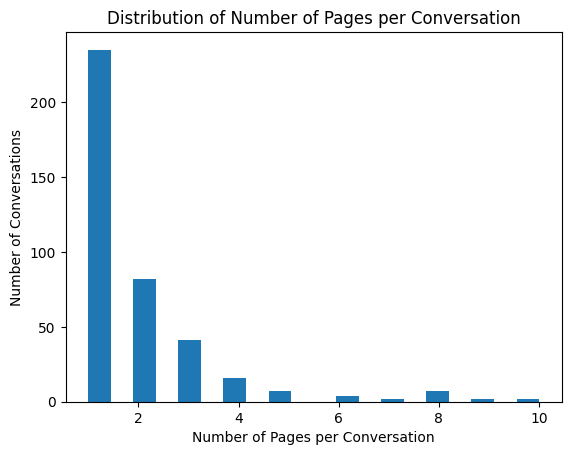

In [9]:
import matplotlib.pyplot as plt

# plot the distribution of number of pages per conversation
page_counts = [len(conv.pages) for conv in conversations]
plt.hist(page_counts, bins=20)
plt.xlabel("Number of Pages per Conversation")
plt.ylabel("Number of Conversations")
plt.title("Distribution of Number of Pages per Conversation")
plt.show()

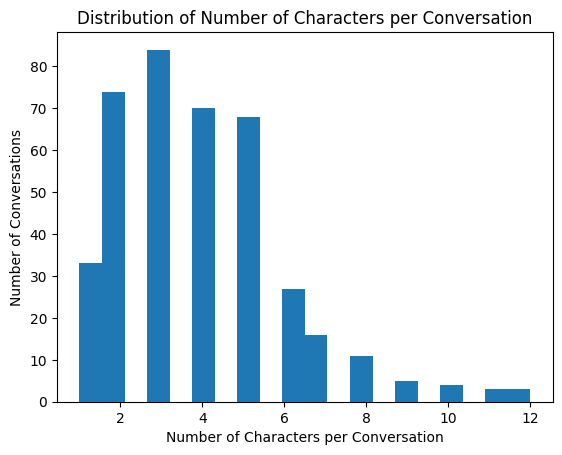

In [10]:
# Plot the distribution of number of characters per conversation
char_counts = [len(conv.characters) for conv in conversations]
plt.hist(char_counts, bins=20)
plt.xlabel("Number of Characters per Conversation")
plt.ylabel("Number of Conversations")
plt.title("Distribution of Number of Characters per Conversation")
plt.show()

In [11]:
# What are the most common characters in the same conversation?
from collections import Counter

char_counter = Counter(
    ",".join(conv.characters)
    for conv in conversations
)
char_counter.most_common(20)

[('paperinik,uno', 58),
 ('everett ducklair,paperinik,uno', 36),
 ('paperinik', 13),
 ('everett ducklair,paperinik', 5),
 ('uno', 5),
 ('evroniano,paperinik,uno', 2),
 ('everett ducklair,paperinik,uno,woman with red hair', 2),
 ('angus fangus,everett ducklair,paperinik,uno,woman with dark curly hair', 1),
 ('everett ducklair,green alien,green robot,isaac (assistant robot),lyla lay,paperinik,red figure,red robot,scientist robot,sound effect,uno,woman in grey suit',
  1),
 ('blond character (luke skywalker parody),man with grey hair and beard,paperinik,uno',
  1),
 ('everett ducklair,lyla lay,muscular red duck,paperinik,red armored duck,red muscular creature,red muscular figure,uno,woman in grey armor',
  1),
 ('green entity (virtual uno),paperinik,uno', 1),
 ('everett ducklair,paperinik,robot (blue),uno', 1),
 ('everett ducklair,military figure,paperinik,purple cloaked character,uno',
  1),
 ('everett ducklair,guard,guard (left),guard (right),paperinik,scrooge mcduck,uno,younger duck in

## Additional reviews

Mark some more pages to be reviewed.

In [12]:
to_review = set[str]()


def mark_for_review(conv: Conversation) -> None:
    """Mark the conversation for review."""
    for page in conv.pages:
        if not page.reviewed:
            to_review.add(page.input_page)

All conversations with Uno alone are suspicious.

In [13]:
# Scores of the conversations with only uno
uno_conversations = [
    conv for conv in conversations if len(conv.characters) == 1 and 'uno' in conv.characters
]
[conv.score for conv in uno_conversations]

[0.0010164592820028529,
 0.0010164592820028529,
 0.0010164592820028529,
 0.00095405194896853,
 0.0008964427197101519]

In [14]:
uno_conversations[0].to_dict()

{'pkna': 'PKNA #5',
 'page_range': [50],
 'characters': ['uno'],
 'score': 0.0010164592820028529,
 'pages': [{'input_page': '../input/pkna/pkna-5/pkna5-052.jpg',
   'pkna': 'PKNA #5',
   'page_num': 50,
   'conv_num': 48,
   'dialogue': [{'character': 'uno',
     'text': 'A dire il vero... non lo era.',
     'confidence': 0.52,
     'uno_confidence': 1.0}],
   'reviewed': False}]}

In [15]:
for conv in uno_conversations:
    mark_for_review(conv)

## Update review file

Keep this as last step.

In [16]:
import json
import os


def into_review(p: Page) -> dict:
    """Only keep the main text and character."""
    return {
        'dialogue': [
            {
                'character': line.character,
                'text': line.text,
            }
            for line in p.dialogue
        ]
    }


def write_review_file(pages: list[Page], filename: str) -> None:
    """Write the review file"""
    data = [
        {
            'image': page.input_page,
            'ocr': into_review(page),
            'full': page.to_dict(),
        }
        for page in pages
        if not page.reviewed
    ]
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    with open(filename, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)


def fetch_pages_from_convos(
        convos: list[Conversation],
        page_filter: set[str],
) -> list[Page]:
    """Fetch pages from conversations."""
    return [
        page for conv in convos
        for page in conv.pages
        if not page.reviewed and page.input_page in page_filter
    ]


# Write the review file for the pages to be reviewed
pages_to_review = fetch_pages_from_convos(conversations, to_review)
write_review_file(pages_to_review, output_review)

## Trim conversations

Remove all messages before Uno speaks for the first time and after he speaks last.

In [24]:
@dataclass
class DatasetDialogue:
    pkna: str
    input_pages: list[str]
    score: float
    dialogue: list[Line]

    def to_dict(self) -> dict:
        return {
            'pkna': self.pkna,
            'input_pages': self.input_pages,
            'score': self.score,
            'dialogue': [line.to_dict() for line in self.dialogue],
        }


def create_dataset(conversations: list[Conversation]) -> list[DatasetDialogue]:
    """Create dataset dialogues from conversations."""
    dialogues = []

    for conv in conversations:
        pkna = conv.pkna
        input_pages = [page.input_page for page in conv.pages]
        dialogue = [line for page in conv.pages for line in page.dialogue]

        if 'uno' not in [l.character for l in dialogue]:
            continue

        # Group together lines with the same character appearing consecutively
        curr_lines: list[Line] = []
        grouped: list[list[Line]] = []
        for line in dialogue:
            if curr_lines and curr_lines[-1].character != line.character:
                grouped.append(curr_lines)
                curr_lines = []
            curr_lines.append(line)
        if curr_lines:
            grouped.append(curr_lines)

        # Create line objects for each group
        dialogue = [
            Line(
                character=group[0].character,
                text="\n".join([l.text for l in group]),
                confidence=float(np.average([l.confidence for l in group])),
                uno_confidence=float(np.average([l.uno_confidence for l in group])),
            )
            for group in grouped
        ]

        # Find the first and last index of lines with 'uno'
        first_uno = next((i for i, line in enumerate(dialogue) if line.character == 'uno'))
        last_uno = len(dialogue) - next((i for i, line in enumerate(reversed(dialogue)) if line.character == 'uno'))
        # Keep only the first line before 'uno' and his last reply.
        first = first_uno-1 if first_uno>0 else 0
        last = last_uno if last_uno<len(dialogue) else len(dialogue)
        dialogue = dialogue[first:last]

        dialogues.append(DatasetDialogue(
            pkna=pkna,
            input_pages=input_pages,
            dialogue=dialogue,
            score=conv.score,
        ))

    return dialogues

dataset = create_dataset(conversations)
dataset[0].to_dict()

{'pkna': 'PKNA #2',
 'input_pages': ['../input/pkna/pkna-2/pkna2-06.jpg',
  '../input/pkna/pkna-2/pkna2-07.jpg',
  '../input/pkna/pkna-2/pkna2-08.jpg',
  '../input/pkna/pkna-2/pkna2-09.jpg',
  '../input/pkna/pkna-2/pkna2-10.jpg',
  '../input/pkna/pkna-2/pkna2-11.jpg',
  '../input/pkna/pkna-2/pkna2-12.jpg',
  '../input/pkna/pkna-2/pkna2-13.jpg',
  '../input/pkna/pkna-2/pkna2-14.jpg',
  '../input/pkna/pkna-2/pkna2-15.jpg'],
 'score': 0.05080927427402708,
 'dialogue': [{'character': 'everett ducklair',
   'text': 'Sei pronto, Paperinik?',
   'confidence': 0.6960000000000001,
   'uno_confidence': 0.2},
  {'character': 'uno',
   'text': 'Sto per escludere il collegamento! Tre... due... uno...\n...Zero! Routine conclusa, fine connessione.',
   'confidence': 0.9219999999999999,
   'uno_confidence': 1.0},
  {'character': 'paperinik',
   'text': "La prossima volta preferirei che l'uscita dal programma fosse meno brusca!\nOuch!",
   'confidence': 0.9219999999999999,
   'uno_confidence': 0.0},
  

In [25]:
import pandas as pd


def to_chat(dialogue: list[Line]) -> list[dict[str, str]]:
    """Convert dialogue lines to chat format. Merge consecutive lines by the
    same character."""
    merged = []
    for line in dialogue:
        role = 'assistant' if line.character == 'uno' else 'human'
        # If the last line is from the same character, merge them
        # Otherwise, create a new entry
        if merged and merged[-1]['role'] == role:
            merged[-1]['content'] += "\n" + line.text
        else:
            merged.append({
                'role': role,
                'content': line.text
            })
    return merged


records = [
    {
        'pkna': d.pkna,
        'input_pages': d.input_pages,
        'characters': sorted(list(set(line.character for line in d.dialogue))),
        'conversations': to_chat(d.dialogue),
        'lines_confidence': [l.confidence for l in d.dialogue],
        'scores': d.score,
    }
    for d in dataset
]

df = pd.DataFrame.from_records(records)
df.head()

,pkna,input_pages,characters,conversations,lines_confidence,scores
0,PKNA #2,"[../input/pkna/pkna-2/pkna2-06.jpg, ../input/p...","[everett ducklair, paperinik, uno]","[{'role': 'human', 'content': 'Sei pronto, Pap...","[0.6960000000000001, 0.9219999999999999, 0.921...",0.050809
1,PKNA #48,"[../input/pkna/pkna-48/pkna57.jpg, ../input/pk...","[everett ducklair, green alien, green robot, l...","[{'role': 'human', 'content': 'che sta dicendo...","[0.88, 0.624, 0.592, 0.9319999999999999, 0.624...",0.050460
2,PKNA #27,"[../input/pkna/pkna-27/pk00007.jpg, ../input/p...","[blond character (luke skywalker parody), man ...","[{'role': 'human', 'content': 'Infatti... dov'...","[0.49333333333333335, 0.848, 0.864, 0.44000000...",0.019786
3,PKNA #48,"[../input/pkna/pkna-48/pkna41.jpg, ../input/pk...","[everett ducklair, lyla lay, muscular red duck...","[{'role': 'human', 'content': 'Niente da fare....","[0.968, 0.936, 1.0, 0.85, 0.88, 0.919999999999...",0.019253
4,PKNA #1,"[../input/pkna/pkna-1/pkna1-26.jpg, ../input/p...","[everett ducklair, paperinik, uno]","[{'role': 'assistant', 'content': 'E ora l'ho ...","[1.0, 1.0, 1.0, 1.0, 1.0, 0.872, 0.823, 1.0, 0...",0.009303


In [26]:
df.to_csv(output_dataset, index=False, encoding='utf-8-sig')